Para implementar el movimiento de un robot móvil 4WD Skid-Steering (SSMR) en Python, resulta importante comprender su modelo cinemático, el cual describe cómo las velocidades de las ruedas se traducen en el desplazamiento del vehículo en el plano.

# Modelo cinematico y ecuaciones de movimiento

El estado del robot en el espacio global se define mediante el vector $q = [X, Y, \theta]^T$, donde $(X, Y)$ representan la posición del centro de masa y $\theta$ es la orientación o ángulo de guiñada (yaw). Las ecuaciones diferenciales que gobiernan su movimiento, bajo la hipótesis de que el deslizamiento lateral es nulo ($x_{ICR} = 0$), son las siguientes:

$\dot{X} = v_x \cos(\theta)$ 

$\dot{Y} = v_x \sin(\theta)$ 

$\dot{\theta} = \omega_z$


Donde $v_x$ es la velocidad lineal longitudinal y $\omega_z$ es la velocidad angular del robot. Estas velocidades del robot se obtienen a partir de las velocidades angulares de las ruedas izquierdas ($\omega_L$) y derechas ($\omega_R$) mediante las relaciones:

$v_x = r \frac{\omega_L + \omega_R}{2}$ 

$\omega_z = r \frac{\omega_R - \omega_L}{2c}$

En estas fórmulas, $r$ es el radio efectivo de las ruedas y $c$ es la mitad de la distancia entre las ruedas de ambos lados (ancho de vía).

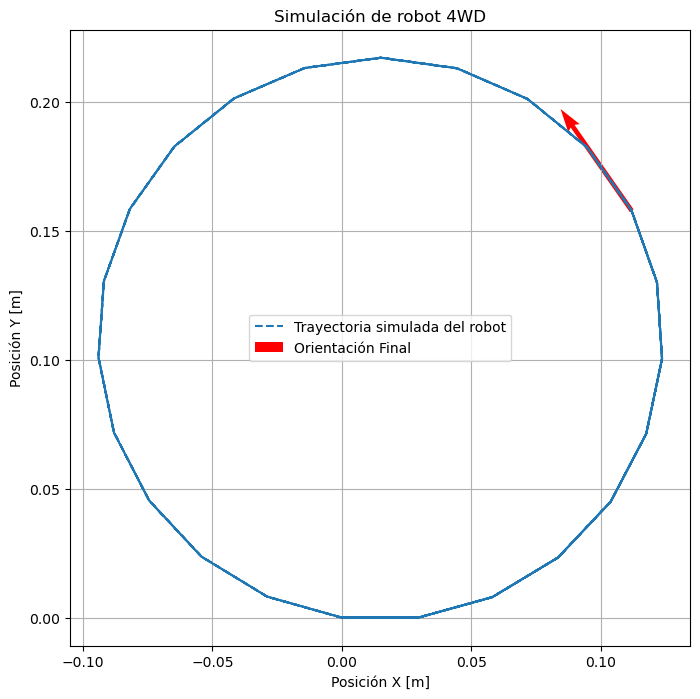

In [2]:
# Importamos librerias para realizar la "simulación"
import numpy as np
import matplotlib.pyplot as plt

#parametros de nuestro robot
r = 0.066 #Radio de las llantas en metros
c = 0.1329 #Mitad del ancho del robot en metros
dt =  0.1 #Paso del tiempo de la simulación

#Estado inicial del robot [X,Y,Theta] 
state = np.array([0.0,0.0,0.0])

# Historial para la simulación
path_x, path_y = [state[0]], [state[1]]

#Definimos ecuaciones de velocidad
def get_velo(w_L,w_R):
    v_x = r * (w_L + w_R)/2
    w_z = r * (w_L - w_R)/(2*c)
    return v_x,w_z

def update_pos(state,v_x,w_z,dt):
    X,Y,Theta =  state

    #Ecuaciones cinematicas
    dx = v_x * np.cos(Theta) * dt
    dy = v_x * np.sin(Theta) * dt
    dtheta = w_z * dt 

    return np.array([ X + dx, Y + dy , Theta + dtheta])


# Ejemplo de "manejo": Avanzar y rotar
# Definimos velocidades de ruedas (rad/s) para una trayectoria curva
w_L = 10.0  # Rueda izquierda
w_R = -1.0  # Rueda derecha (más rápida para girar a la izquierda)

# Bucle de simulación por 10 segundos
for _ in range(int(10/dt)):
    v_x, w_z = get_velo(w_L, w_R)
    state = update_pos(state, v_x, w_z, dt)
    path_x.append(state[0])
    path_y.append(state[1])


plt.figure(figsize=(8,8))
plt.plot(path_x,path_y,'--',label = 'Trayectoria simulada del robot')
plt.quiver(state[0], state[1], np.cos(state[2]), np.sin(state[2]), 
           color='red', scale=5, label='Orientación Final')
plt.ylabel("Posición Y [m]")
plt.xlabel("Posición X [m]")
plt.title("Simulación de robot 4WD")
plt.legend()
plt.grid()
plt.show()



# Uso de  programación orientada a objetos (POO) para la implementación del robot

In [6]:
import numpy as np

class Robot4WD:
    #Definimos el inicializador
    def __init__(self,x=0,y=0,theta=0): 
        
        
        #Parametros fisicos
        self.r = 0.066 #Radio de la rueda en metros
        self.c = 0.1329 #Mitad del ancho del robot en metros

        #Definimos el estado inicial del robot
        #[x,y,theta]
        self.state = np.array([x,y,theta],dtype=float) #Originalmente tendra Ceros

    def wheel_speed(self,v,w): #inverse Kinematics
        '''
        Qué tan rapido deben girar los motores izquierdo y derecho si 
        quiero que el robot avance a x m/s y gire a x rad/s
        '''

        #Convertimos comandos globales de velocidad a rad/s para cada lado
        w_L = (v - (w * self.c/2))/self.r #velocidad izquierda
        w_R = (v + (w * self.c/2))/self.r   #Velocidad derecha
        return w_L,w_R
   
    #Definimos el modelo cinematico
    def kinematic_mod(self,v,w,dt): #Direct kinematics
        '''
        Mis motores estan moviento a x velocidad, dime donde termina el robot en el mapa
        '''

        #Actualizar la posición basada en velocidad lineal v y angular w
        x ,y ,theta = self.state
        dx = v * np.cos(theta)
        dy = v * np.sin(theta)
        dtheta = w

        #Actualizamos la posición    
        self.state += np.array([dx,dy,dtheta]) * dt
        #Normalizamos theta entre -pi y pi 
        self.state[2] = np.arctan2(np.sin(self.state[2]),np.cos(self.state[2]))

# Ejercicio 1
### Objetivo: Hacer que el robot rote exactamente 90,180 y 360 grados sobre su propio eje y  se detenga
### Reto: Implementar un pequeño error de "ruido" en las velocidades de las ruedas en el codigo y observar como el robot ya no termina en el angulo exacto

* **Uso de `plt.quiver`:** Esta función dibuja flechas. Necesita la posición $(x, y)$ y la dirección $(u, v)$. Para representar la orientación $\theta$, usamos $u = \cos(\theta)$ y $v = \sin(\theta)$.

* **Visualización:** Como el robot rota sobre su eje, su posición $(x, y)$ siempre es $(0, 0)$. Si dibujas mil flechas en el mismo punto, solo verás un manchón. Es mejor guardar la historia o dibujar solo el estado final.

Iniciando rotación de 180.0
Angulo final alcanzado: -179.80 Grados


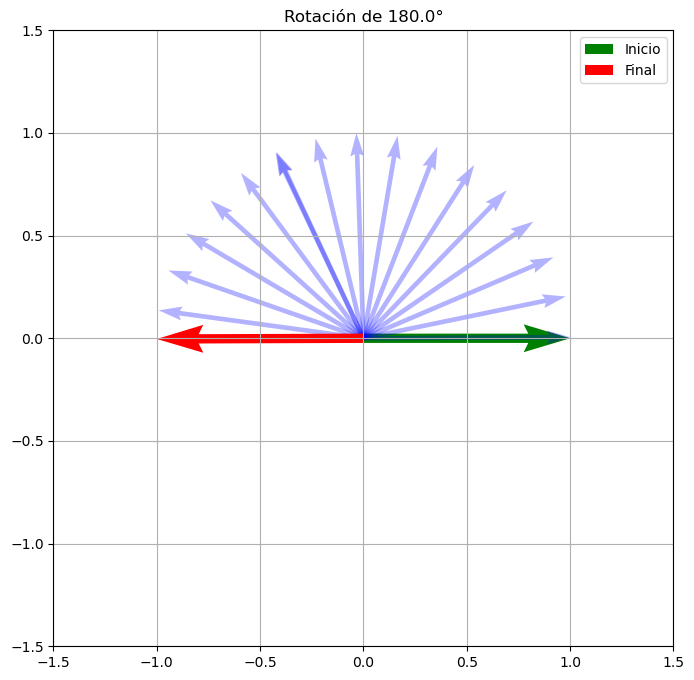

In [65]:
#Comenzamos por instanciar un objeto de la clase robot
robot = Robot4WD(x=0,y=0,theta=0)
dt = 0.01 #Paso del tiempo pequeño para mayor presición en la simulación
angulos_target = [np.pi * 2 ,np.pi, np.pi/2] # 360,180,90 Grados objetivos para este ejercicio
w_deseada = 0.5 #es la velocidad angular a la que girara el robot y en este ejercicio podemos definirla y recordar que es en rad/s

#seguimos por calcular el tiempo necesario en el cual nuestro robot debera realizar el giro para alcanzar los angulos deseados
t_necesario = [angle/w_deseada for angle in angulos_target] 

#maquillamos la grafica antes de graficar 
plt.figure(figsize=(8,8))


#Avanzamos con definir el bucle de simulación (para un angulo en especifico)
print(f"Iniciando rotación de {np.degrees(angulos_target[1])}")
historial_path = [] #Necesitamos algo para almacenar las posiciones
historial_path.append(robot.state[2]) #Guardamos el primer estado

plt.quiver(robot.state[0], robot.state[1], 
           np.cos(robot.state[2]), np.sin(robot.state[2]), 
           angles='xy', scale_units='xy', scale=1, color='green', label="Inicio", width=0.015)

for t in np.arange(0,t_necesario[1],dt):
    #Suponiendo que en este ejercicio v_lineal = 0 para rotaar sobre el eje, tenemos
    v_input = 0
    w_input = w_deseada

    '''
    Sabemos el angulo y la velocidad en la que queremos alcanzarlo, 
    es hora de calcular la velocidad a la que debemos actuar las ruedas'''

    w_L, w_R = robot.wheel_speed(v_input,w_input) #Nos dice los pwm que enviaremos a los motores (no necesarios para esta simulación)

    #Actualizamos ahora la posición en la simulación (esto actualiza el state del robot)
    robot.kinematic_mod(v_input,w_input,dt)
    historial_path.append(robot.state[2])


    #---Estetico---
    #Añadimos la posibilidad de graficar los cambios del robot
    if int(t/dt) % 40 == 0:
        plt.quiver(robot.state[0],robot.state[1],
                   np.cos(robot.state[2]),np.sin(robot.state[2]),
                   angles = 'xy', scale_units = 'xy', scale = 1, color = 'blue', alpha = 0.3)

plt.quiver(robot.state[0], robot.state[1], 
           np.cos(robot.state[2]), np.sin(robot.state[2]), 
           angles='xy', scale_units='xy', scale=1, color='red', label="Final", width=0.015)
    
# Detalles estéticos
print(f"Angulo final alcanzado: {np.degrees(robot.state[2]):.2f} Grados")
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.title(f"Rotación de {np.degrees(angulos_target[1])}°")
plt.legend()
plt.grid(True)
plt.show()


# Ejercicio 2: "Go-to-Goal" (Hacia el objetivo)
### Objetivo: Crea una función `drive_to_point(target_x, target_y)`.

### Lógica: El robot debe calcular el ángulo hacia el punto, rotar, y luego avanzar.

### Mejora: Haz que el robot reduzca la velocidad lineal a medida que se acerca al punto para evitar sobrepasarlo (overshoot).

Para llegar a un punto, el robot debe:
1.- Calcular qué tan lejos se encuentra del objetivo $distancia \sqrt{(x_d - x)^2 + (y_d-y)^2}$
2.- Calcuilar qué angulo debe tener para "mirar" el objetivo: $\theta_\textit{deseado}=atan2(y_d-y,x_d-x)$
3.- Ajustar su velocidad angular ($\omega$) para corregir el error de ángulo y su velocidad lineal ($v$) para cercarse

[1.98993177 1.98296442 1.03701154] 2.1949641326735048e-07


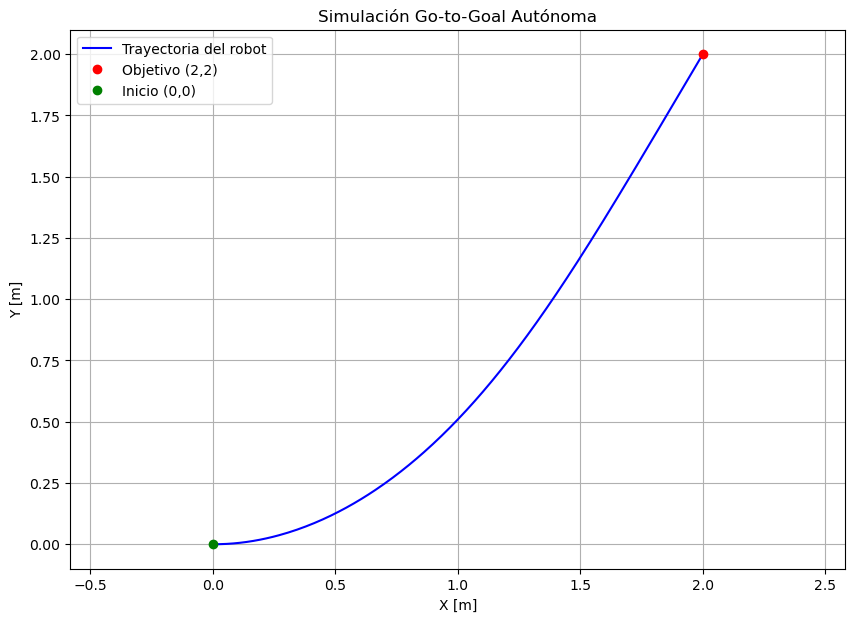

In [9]:
#Comienzo definiendo la función pedida
def drive_to_point(robot_state,target):
    #ubicamos al robot en el mapa en su posición actual
    curr_x,curr_y,curr_theta = robot_state #Posicion actual del robot en cada iteración
    #calculamos los errores entre la posición/inclinación actual con el deseado
    dx = target[0] - curr_x
    dy = target[1] - curr_y
    
    #Calculamos la distancia al objetivo en esa iteración
    distancia = np.sqrt(dx**2 + dy**2)
    #Calculamos angulo hacia el objetivo para esa iteración
    theta_goal = np.arctan2(dy,dx)

    #Calculamos el error de angulo de orientación (Y  de paso lo normalizamos)
    error_theta = np.arctan2(np.sin(theta_goal-curr_theta),np.cos(theta_goal-curr_theta))

    return distancia,error_theta
    


#Instanciamos nuevamente el robot
robot = Robot4WD(0,0,0)
goal = np.array([2.0,2.0])#Coordenadas objetivo
dt = 0.01
v = 0.5 #Velocidad lineal (lo rapido que avanza)
w_deseada = 2.0 #Velocidad de rotación para la corrección de angulos

path_x,path_y = [robot.state[0]],[robot.state[1]] #Las posiciones por las que pasara el robot (las primeras son el origen del robot)


for _ in range(int(10/dt)): #Simular 50 segundos
    distancia,error_theta = drive_to_point(robot.state,goal) #calculamos la distancia y el error de orientación
    
    # Si la distancia es > 1e-6, el robot debe moverse
    if distancia > 1e-6:
        v_input = v * distancia # A más distancia, más velocidad
        w_input = w_deseada * error_theta # A más error de ángulo, más giro
    else:
        v_input, w_input = 0, 0 # ¡Llegamos!
        print("LLegamos al objetivo")
        break
    #Dentro del ciclo actualizamos la posición del robot
    robot.kinematic_mod(v_input,w_input,dt)
    #Almacenamos las nuevas posiciones en sus listas
    path_x.append(robot.state[0])
    path_y.append(robot.state[1])

print(robot.state, error_theta)
#Maquillamos la grafica
plt.figure(figsize=(10,7))
plt.plot(path_x, path_y, 'b-', label="Trayectoria del robot")
plt.plot(goal[0], goal[1], 'ro', label="Objetivo (2,2)")
plt.plot(0, 0, 'go', label="Inicio (0,0)")
plt.xlabel("X [m]"); plt.ylabel("Y [m]")
plt.title("Simulación Go-to-Goal Autónoma")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


# Simulando que hay un obstaculo en el camino basado en campos potencials y fuerzas atractoraas y repulsivas
**La Lógica Matemática**:
Vectores de FuerzaPara implementar esto, necesitamos calcular dos vectores en cada paso de la simulación:

* A. **Fuerza Atractiva** ($\vec{F}_{att}$)

Es el vector que apunta directamente al objetivo. Su magnitud depende de la distancia al objetivo.$$\vec{F}_{att} = k_{att} \cdot (\text{Objetivo} - \text{Posición Actual})$$
* B. **Fuerza Repulsiva** ($\vec{F}_{rep}$) 

Esta solo aparece si el robot está cerca del obstáculo (dentro de un "radio de influencia" $\rho_0$). Si la distancia al obstáculo ($d_{obs}$) es menor que $\rho_0$, el robot siente un empujón en dirección contraria:$$\vec{F}_{rep} = \eta \cdot \left( \frac{1}{d_{obs}} - \frac{1}{\rho_0} \right) \frac{1}{d_{obs}^2} \cdot \hat{u}_{rep}$$

Donde $\hat{u}_{rep}$ es el vector unitario que apunta desde el obstáculo hacia el robot.
* C. **Fuerza Resultante** ($\vec{F}_{total}$)Simplemente sumamos ambos vectores:$$\vec{F}_{total} = \vec{F}_{att} + \vec{F}_{rep}$$Esta resultante nos dirá el nuevo "objetivo virtual" al que el robot debe mirar.


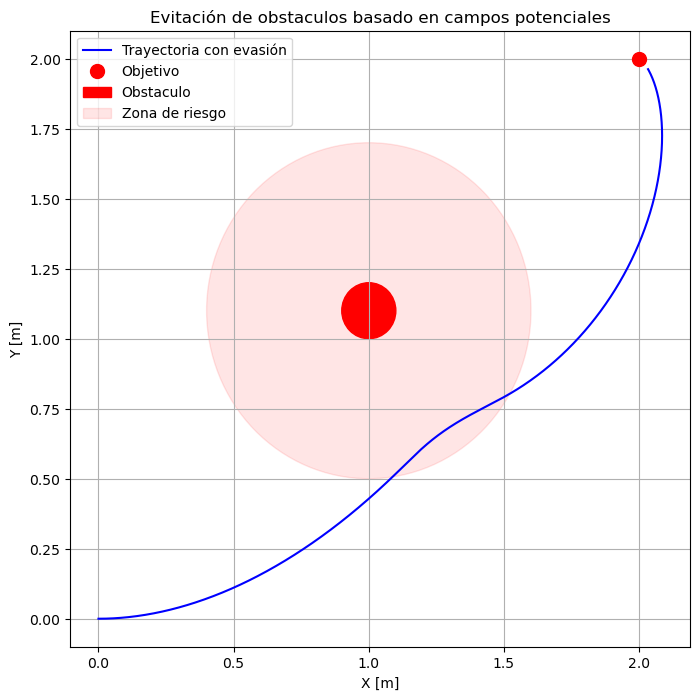

In [10]:
#Mantenemos la inicialización del robot, el objetivo, el dt y la función drive_to_point sin cambios de la linea anterior
robot = Robot4WD(0,0,0)
goal = np.array([2.0,2.0])
obstacle = np.array([1.0,1.1])
#Definimos el radio de influencia
r_influencia = 0.6 #Distancia a la que el robot debe empezar a considerar el objetivo
dt = 0.01
path_x,path_y = [robot.state[0]],[robot.state[1]] #Listas de posición
eta = 2 #Constante de magnitud para la fuerza de repulsión


for _ in range(3000):
    curr_pos = robot.state[:2]#Tomamos las posiciones del robot (menos su angulo)
    
    #Calculamos el vector de fuerza atractiva (qué tan cerca estamos del obj)
    v_att = goal-curr_pos

    #calculamos el vector de repulsión (qué tan lejos estamos del obj)
    dis_obs = np.linalg.norm(curr_pos-obstacle) #Es la norma, la distancia 
    v_rep = np.array([0.0,0.0])

    if dis_obs < r_influencia:
        #Dirección desde el obstaculo al robot
        dir_rep = (curr_pos - obstacle)/dis_obs #Vector unitario del empujo que sufrira el robot (imaginar que lo ira empujando)
        #magnitud = eta * (1/d - 1/rho) * (1d^2)
        #magnitud de la reppulsión (crecera fuadraticamente al acercarce)
        magnitud_rep = eta * (1.0/dis_obs - 1.0/r_influencia) * (1/dis_obs**2)
        v_rep = dir_rep * magnitud_rep
    
    #Se calcula el vector resultante
    v_final = v_att + v_rep

    #Calculamos el error de angulo hacia la direccioón de v_final
    target_theta = np.arctan2(v_final[1],v_final[0])
    error_theta = np.arctan2(np.sin(target_theta-robot.state[2]),
                             np.cos(target_theta-robot.state[2]))
    

    #Distancia al objetivo

    dist_goal = np.linalg.norm(goal-curr_pos)
    #Control de velocidad
    if dist_goal > 0.05:
        v_input = 0.4 * np.tanh(dist_goal)
        w_input = 0.5 * error_theta #El parametrto de velocidad angular puede hacernos pasarnos del objetivo o caer directos en el pozo

    else:
        v_input,w_input = 0,0
        break

    #Calculamos las posiciones y las agregamos a sus listas
    robot.kinematic_mod(v_input,w_input,dt)
    path_x.append(robot.state[0])
    path_y.append(robot.state[1])

#Maquillamos la grafica
plt.figure(figsize=(8,8))
plt.plot(path_x,path_y,'b-',label='Trayectoria con evasión')
plt.plot(goal[0],goal[1],'ro',markersize = 10,label = "Objetivo")

#Dibujamos el obstaculo y su zona de influencia
circle = plt.Circle(obstacle,0.1,color = 'red', label ="Obstaculo")
influence = plt.Circle(obstacle,r_influencia,color = 'red',alpha = 0.1, label = "Zona de riesgo")
plt.gca().add_patch(circle)
plt.gca().add_patch(influence)

plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Evitación de obstaculos basado en campos potenciales")
plt.grid()
plt.legend()
plt.show()


## Probando con varios obstaculos

Para manejar múltiples obstáculos (o "minas"), aplicamos el **Principio de Superposición**. Matemáticamente, esto significa que la fuerza repulsiva total es simplemente la suma vectorial de todas las fuerzas repulsivas individuales:$$\vec{F}_{total} = \vec{F}_{att} + \sum_{i=1}^{n} \vec{F}_{rep, i}$$

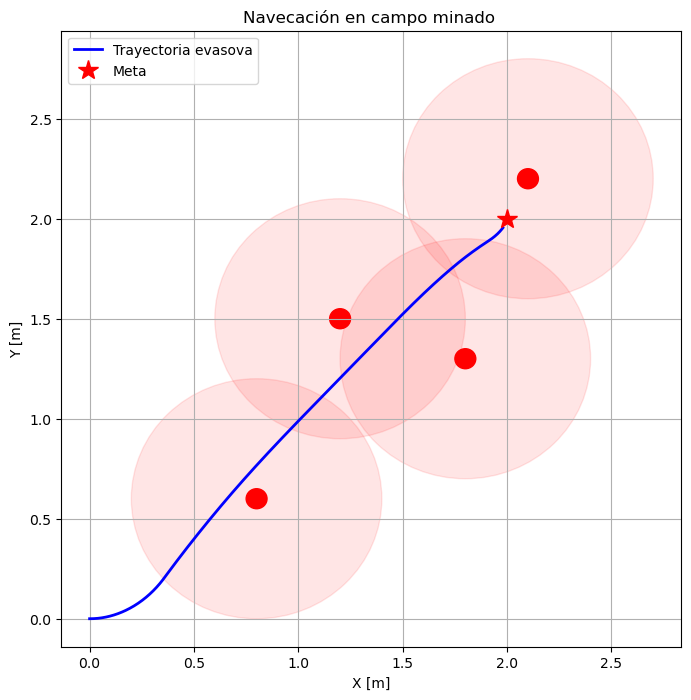

In [11]:
#Instanciamos el robot y el objetivo
robot = Robot4WD(0,0,0)
goal = np.array([2.0,2.0])

#Definimos la lista de obstaculos (minas)
obstacles = [np.array([0.8,0.6]),
             np.array([1.2,1.5]),
             np.array([1.8,1.3]),
             np.array([2.1,2.2])]

#Parametros de control
eta = 0.2 #Ganancia repulsiva
r_influencia = 0.6 #definimos uno en general para cada obstaculo
dt = 0.01
path_x,path_y = [robot.state[0]],[robot.state[1]]

for _ in range(4000):
    #Obtenemos la posición de la iteración
    curr_pos = robot.state[:2]

    #Calculamos el vector de fuerza atractiva (qué tan cerca estamos del obj)
    v_att = goal-curr_pos

    #Debemos ahora de considerar todas las aportaciones repulsivas
    v_rep_total = np.array([0.0,0.0])

    for obs in obstacles:
        #Calculamos la distancia a los obstaculos
        dist_obs = np.linalg.norm(curr_pos - obs)

        if dist_obs < r_influencia:
            #Evitamos división por cero por precausión
            dist_obs = max(dist_obs,0.05)

            #Dirección (el vector unitario)
            dir_rep = (curr_pos-obs)/dist_obs

            #Formula general de repulsión
            magnitud_rep = eta * (1.0/dis_obs - 1.0/r_influencia) * (1/dis_obs**2)

            #Limitamos la fuerza para estabilidd númerica
            magnitud_rep = min(magnitud_rep,10.0)

            #Calculamos el vector total de fuerzas de repulsión
            v_rep_total += dir_rep * magnitud_rep
        
            #Vector resultante de sumar todas las fuerzas repulsivas y atractoras
            v_final = v_att + v_rep_total
        target_theta = np.arctan2(v_final[1],v_final[0])
        error_theta = np.arctan2(np.sin(target_theta-robot.state[2]),
                                 np.cos(target_theta-robot.state[2]))
        
        #Calculamos la distancia al objetivo
        dist_goal = np.linalg.norm(goal-curr_pos)

        if dist_goal > 0.05:
            v_input = 0.4 * np.tanh(dist_goal)
            w_input = 0.5 * error_theta #El parametrto de velocidad angular puede hacernos pasarnos del objetivo o caer directos en el pozo

        else:
            v_input,w_input = 0,0
            break

        #Calculamos las posiciones y las agregamos a sus listas
        robot.kinematic_mod(v_input,w_input,dt)
        path_x.append(robot.state[0])
        path_y.append(robot.state[1])

# -- Graficas ---

plt.figure(figsize=(8,8))
plt.plot(path_x,path_y,'b-',label = "Trayectoria evasova",lw = 2)
plt.plot(goal[0],goal[1],'r*', markersize = 15, label ="Meta")

#Graficamos los obstaculos
for i, obs in enumerate(obstacles):
    color = 'red'
    plt.gca().add_patch(plt.Circle(obs,0.05,color=color))
    plt.gca().add_patch(plt.Circle(obs,r_influencia,color=color,alpha = 0.1))

plt.title("Navecación en campo minado ")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.grid()
plt.legend()
plt.show()




# Probando alcanzar varios objetivosy esquivando los obstaculos

### Lógica del progama

1. Calculamos la distancia al **objetivo actual**
2. Si la distancia es menor a un determinado umbral, consideramos que helos "llegado" al objetivo en turno
3. **Cambiamos el objetivo**: pasamos al siguiente punto de la lista de objetivos
4. Si ya visitamos todos los objetivos, el robot se detiene 

Objetivo 1 alcanzado, pasando al siguiente


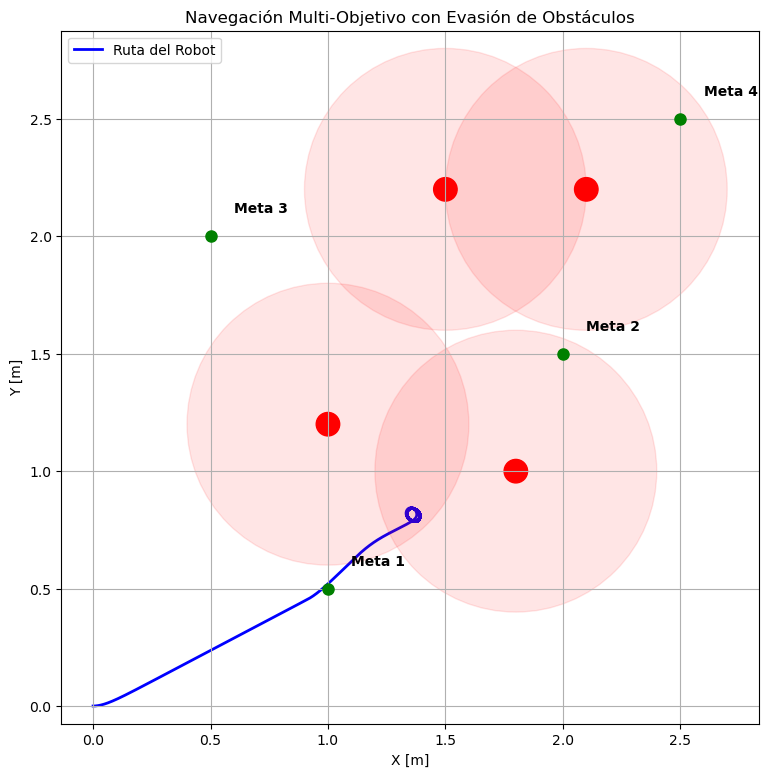

In [16]:
#Instanciamos el robot y la lista de ojetivos
robot = Robot4WD(0,0,0)
goals = [np.array([1.0,0.5]),
          np.array([2.0,1.5]),
          np.array([0.5,2.0]),
          np.array([2.5,2.5])]

#Definimos los obstaculos
obstacles = [np.array([1.0,1.2]),
             np.array([1.8,1.0]),
             np.array([1.5,2.2]),
             np.array([2.1,2.2])]

#Caracteristicas del problema
eta = 0.5
r_influencia = 0.6
dt = 0.01
umbral = 0.1 #Umbral para considerar la meta alcanzada

#Listas de puntos
path_x,path_y = [robot.state[0]],[robot.state[1]]

#idx de los objetivos (sirve par ir contando)
obj_idx = 0 

#bucle de simulación
for _ in range(6000):#60 segundos de la simulación
    #Consideramos la posición del robot
    curr_pos = robot.state[:2]

    #Seleccionamos el objetivo actual de la lista
    goal = goals[obj_idx]

    #Calculamos la fuerza atractiva
    v_att = goal - curr_pos

    #Calculamos el total de fuerza repulsiva de la suma de obstaculos
    v_rep_total = np.array([0.0,0.0]) #Se inicia cero para considerar el aporte neto en cada segundo y no el total del tiempo
    for obs in obstacles:
        #Calculamos la distancia al objetivo
        dist_obs = np.linalg.norm(curr_pos-obs)
        #Si estamos más alla del radio de influencia debemos sufrir la fuerza de repulsión
        if dist_obs < r_influencia:
            dist_obs = max(dist_obs,0.05) #Es para cuidarnos de pasarnos númericamente muy cerca del cero de distancia
            dir_rep = (curr_pos-obs)/dist_obs #Recuerda que este es solo el vector unitario del empuje
            #Esta es la formula cuadratica de repulsión
            magnitud_rep = eta * (1.0/dist_obs - 1.0/r_influencia)*(1.0/dist_obs**2)
            v_rep_total += dir_rep*magnitud_rep #Se suma el total de todos los obstaculos
    
    #Calculamos el vector resultante
    v_final = v_att + v_rep_total 

    #V_final es como si ahora fuera el punto o objetivo actual

    #Pasamos al control de navegacióin para darle sentido al robot
    target_theta = np.arctan2(v_final[1],v_final[0]) #Obtenemos el angulo de inclinación en donde se encuentra nuestro objetivo tras sufrir los empujes  y jalones
    error_theta = np.arctan2(np.sin(target_theta-robot.state[2]),
                             np.cos(target_theta-robot.state[2])) #El error entre el angulo de nuestro robot y el del  objetivo actual
    
    #Calculamos la distancia al objetivo actual y el robot
    dist_obj_actual = np.linalg.norm(goal - curr_pos)

    #Cambio de objetivo
    if dist_obj_actual < umbral:
        print(f"Objetivo {obj_idx + 1} alcanzado, pasando al siguiente")
        #Aumentamos el obj_idx
        obj_idx += 1
        #si el número de objetivos contados es mayor a la longitud de la lista de objetivos, debe apagar el robot
        if obj_idx >= len(goals):
            print("Todos los objetivos han sido alcanzados con exito")
            break
        continue #Se sigue la iteración con el nuevo objetivo (iniciamos el ciclo nuievamente)
    
    #---Mover el robot---
    #Calculamos las velcoidades lineales y angulares
    v_input = 0.3 * np.tanh(dist_obj_actual)
    w_input = 5.0 * error_theta

    #Actualizamos la posición del robot (state)
    robot.kinematic_mod(v_input,w_input,dt)
    path_x.append(robot.state[0])
    path_y.append(robot.state[1])

# --- 4. Visualización ---
plt.figure(figsize=(9,9))
plt.plot(path_x, path_y, 'b-', label="Ruta del Robot", linewidth=2, zorder=1)

# Dibujar Waypoints
for i, wp in enumerate(goals):
    plt.plot(wp[0], wp[1], 'go', markersize=8)
    plt.text(wp[0]+0.1, wp[1]+0.1, f"Meta {i+1}", fontsize=10, fontweight='bold')

# Dibujar Obstáculos
for obs in obstacles:
    plt.gca().add_patch(plt.Circle(obs, 0.05, color='red'))
    plt.gca().add_patch(plt.Circle(obs, r_influencia, color='red', alpha=0.1))

plt.title("Navegación Multi-Objetivo con Evasión de Obstáculos")
plt.xlabel("X [m]"); plt.ylabel("Y [m]"); plt.axis('equal'); plt.grid(True)
plt.legend(); plt.show()


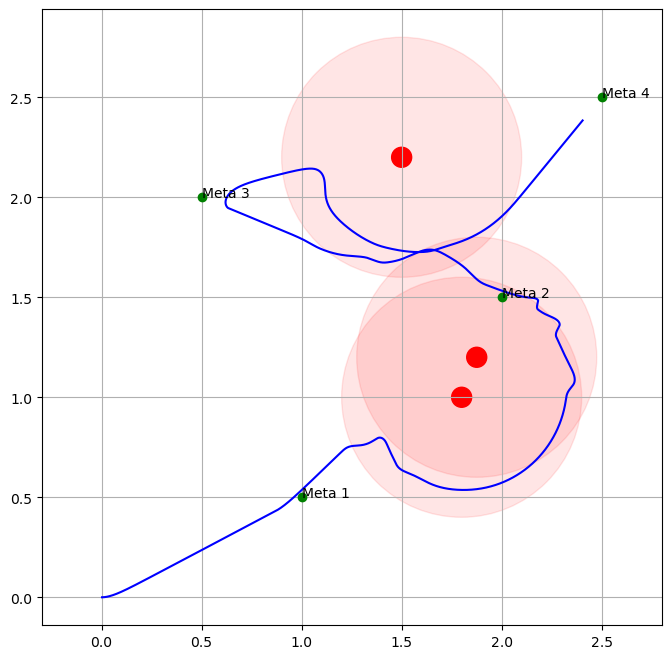

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración ---
robot = Robot4WD(x=0, y=0, theta=0)
goals = [np.array([1.0, 0.5]), np.array([2.0, 1.5]), np.array([0.5, 2.0]), np.array([2.5, 2.5])]

# Obstáculos iniciales
obs_positions = [
    np.array([1.4, 1.2]),
    np.array([1.8, 1.0]),
    np.array([1.5, 2.2])
]

eta = 0.4
r_influencia = 0.6
dt = 0.01
obj_idx = 0
path_x, path_y = [], []

# --- Bucle de Simulación ---
for t_step in range(8000):
    curr_pos = robot.state[:2]
    goal = goals[obj_idx]
    
    # 1. Movimiento de Obstáculos (¡Las minas patrullan!)
    # Hacemos que la primera mina se mueva de izquierda a derecha
    obs_positions[0][0] = 1.4 + 0.5 * np.sin(t_step * 0.02)
    
    # 2. Fuerzas
    v_att = goal - curr_pos
    v_rep_total = np.array([0.0, 0.0])
    
    for obs in obs_positions:
        dist_obs = np.linalg.norm(curr_pos - obs)
        if dist_obs < r_influencia:
            dist_obs = max(dist_obs, 0.05)
            dir_rep = (curr_pos - obs) / dist_obs
            
            # Magnitud Repulsiva
            mag = eta * (1.0/dist_obs - 1.0/r_influencia) * (1.0/dist_obs**2)
            f_rep = dir_rep * min(mag, 5.0)
            
            # NUEVO: Fuerza Tangencial (ayuda a evitar mínimos locales)
            # Rotamos el vector repulsivo 90 grados
            f_tan = np.array([-f_rep[1], f_rep[0]]) * 0.5 
            
            v_rep_total += (f_rep + f_tan)

    v_final = v_att + v_rep_total
    
    # 3. Control
    target_theta = np.arctan2(v_final[1], v_final[0])
    error_theta = np.arctan2(np.sin(target_theta - robot.state[2]), np.cos(target_theta - robot.state[2]))
    
    dist_goal = np.linalg.norm(goal - curr_pos)
    if dist_goal < 0.15: # Umbral un poco más grande para evitar atascos
        obj_idx += 1
        if obj_idx >= len(goals): break
        continue

    v_input = 0.25 * np.tanh(dist_goal)
    w_input = 4.0 * error_theta # Bajamos un poco la ganancia para suavizar
    
    robot.kinematic_mod(v_input, w_input, dt)
    path_x.append(robot.state[0]); path_y.append(robot.state[1])

# --- Gráfica ---
plt.figure(figsize=(8,8))
plt.plot(path_x, path_y, 'b-', label="Trayectoria Fluida")
for i, g in enumerate(goals): plt.plot(g[0], g[1], 'go'); plt.text(g[0], g[1], f"Meta {i+1}")
for obs in obs_positions:
    plt.gca().add_patch(plt.Circle(obs, 0.05, color='red'))
    plt.gca().add_patch(plt.Circle(obs, r_influencia, color='red', alpha=0.1))
plt.axis('equal'); plt.grid(True); plt.show()

# **Ejercicio 3**. El "Ocho" (Trayectoria Continua)
* Objetivo: Define una trayectoria paramétrica (como una curva de **Lissajous** o un simple ocho).
* Reto: El robot debe seguir el camino sin detenerse. Aquí es donde usarás las ecuaciones de la tesis para calcular $v$ y $\omega$ en cada paso de tiempo $dt$.
En el ejercicio anterior el objetivo era estático. Ahora, el objetivo se mueve.
Para hacer un "ocho", el target_x y target_y deben cambiar en cada paso del tiempo usando una función seno y coseno:
* $x_{ref}(t) = A \cdot \sin(\omega_t \cdot t)$
* $y_{ref}(t) = A \cdot \sin(\omega_t \cdot t) \cdot \cos(\omega_t \cdot t)$

Hint: Intenta modificar el bucle for para que en cada iteración el goal cambie según el tiempo t. ¿Te sientes listo para intentarlo o prefieres que te de la estructura base?

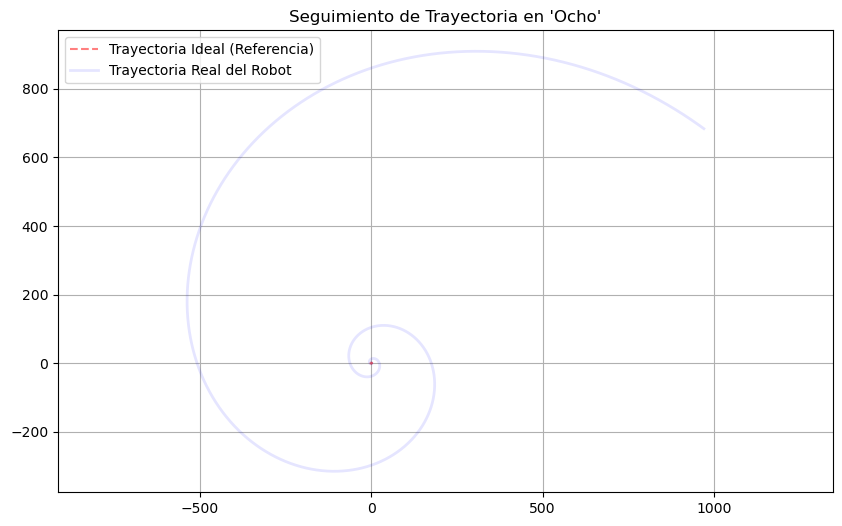

In [ ]:
#Se comienza por inicializar el robot
robot = Robot4WD(0,0,0)
dt = 0.001
sim_time = 40 #Seguindos de simulación
steps = int(sim_time/dt)

#"Ganancias" de control
v = 1.0 #Velocidad lineal
w= 0.5 #Velocidad angular de rotación del robot

#La lista de sus posiciones tanto del robot como del punto objetivo
path_x, path_y = [robot.state[0]],[robot.state[1]]
ref_x, ref_y = [],[] #Para comparar la trayectoria ideal vs la real


def get_ref(t):
    #Genera la figura parametrizada (un 8 en este caso) basada en el tiempo actual
    A = 1.5 
    w_t = 0.3 #Frecuencia de oscilación

    #Función para generar las posiciones objetivo
    x_ref = A * np.sin(w_t * t)
    y_ref = A * np.sin(w_t * t) * np.cos(w_t * t)
    return x_ref,y_ref


# --- Funciones de control --- 
def control(robot_state, target):
    """
    Calcula el error de distancia y de orientación.
    robot_state: [x, y, theta]
    target: [x_target, y_target]
    """
    # 1. Vector del robot al objetivo
    dx = target[0] - robot_state[0]
    dy = target[1] - robot_state[1]

    # 2. Distancia euclidiana (Usando linalg.norm sobre el vector diferencia)
    dist_obj = np.sqrt(dx**2 + dy**2)
    
    # 3. Ángulo deseado para "mirar" al objetivo
    # ¡Aquí estaba el detalle! Usamos el vector relativo dx, dy
    theta_goal = np.arctan2(dy, dx)
    
    # 4. Error de orientación (Normalizado entre -pi y pi)
    error_theta = np.arctan2(np.sin(theta_goal - robot_state[2]),
                             np.cos(theta_goal - robot_state[2]))
    
    return dist_obj, error_theta

# -- Simulación --
for i in range(steps):
    t_actual = i*dt #Así el tiempo avanzara
    #Obtenemos el objetivo en este intante de tiempo
    x_target,y_target = get_ref(t_actual)
    #Calculamos las distancias y errores de orientación
    dist_error,error_theta = control(robot.state,(x_target,y_target))

    #Control
    #El robot siempre debería intentar alcanzar el punto movil
    v_input = v * dist_error
    w_input = w * error_theta

    #Actualizamos la posición
    robot.kinematic_mod(v_input,w_input,dt)
    path_x.append(robot.state[0])
    path_y.append(robot.state[1])
    #Actualizamos la posición del punto objetivo
    ref_x.append(x_target)
    ref_y.append(y_target)


# -- Maquillamos la grafica ---
plt.figure(figsize=(10,6))
plt.plot(ref_x, ref_y, 'r--', alpha=0.5, label="Trayectoria Ideal (Referencia)")
plt.plot(path_x, path_y, 'b-', linewidth=2, label="Trayectoria Real del Robot",alpha=0.5)
plt.title("Seguimiento de Trayectoria en 'Ocho'")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()








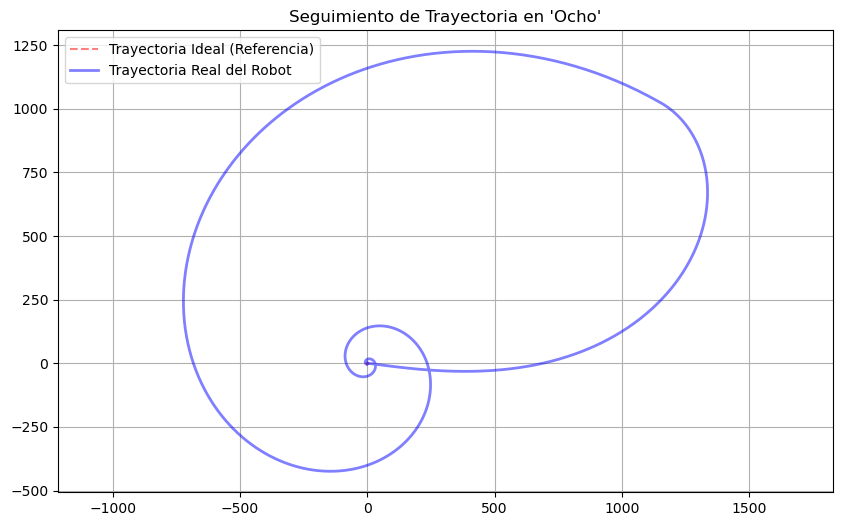

In [50]:
# --- Funciones de control --- 
def control(robot_state, target):
    """
    Calcula el error de distancia y de orientación.
    robot_state: [x, y, theta]
    target: [x_target, y_target]
    """
    # 1. Vector del robot al objetivo
    dx = target[0] - robot_state[0]
    dy = target[1] - robot_state[1]

    # 2. Distancia euclidiana (Usando linalg.norm sobre el vector diferencia)
    dist_obj = np.sqrt(dx**2 + dy**2)
    
    # 3. Ángulo deseado para "mirar" al objetivo
    # ¡Aquí estaba el detalle! Usamos el vector relativo dx, dy
    theta_goal = np.arctan2(dy, dx)
    
    # 4. Error de orientación (Normalizado entre -pi y pi)
    error_theta = np.arctan2(np.sin(theta_goal - robot_state[2]),
                             np.cos(theta_goal - robot_state[2]))
    
    return dist_obj, error_theta

# -- Simulación --
# (Asegúrate de que K_v y K_w sean valores que no saturen los motores)
Kv = 1.5 
Kw = 4.0 

for i in range(steps):
    t_actual = i * dt
    x_target, y_target = get_ref(t_actual)
    
    # Pasamos el estado completo [x, y, theta]
    dist_error, error_theta = control(robot.state, (x_target, y_target))

    # Ley de control proporcional
    v_input = Kv * dist_error
    w_input = Kw * error_theta

    # Actualizamos el robot
    robot.kinematic_mod(v_input, w_input, dt)
    
    # Guardamos datos
    path_x.append(robot.state[0])
    path_y.append(robot.state[1])
    ref_x.append(x_target)
    ref_y.append(y_target)
# -- Maquillamos la grafica ---
plt.figure(figsize=(10,6))
plt.plot(ref_x, ref_y, 'r--', alpha=0.5, label="Trayectoria Ideal (Referencia)")
plt.plot(path_x, path_y, 'b-', linewidth=2, label="Trayectoria Real del Robot",alpha=0.5)
plt.title("Seguimiento de Trayectoria en 'Ocho'")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()
